In [3]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [4]:
data_path = 'data/scraped_data_team_43.csv'
df = pd.read_csv(data_path)

In [5]:
def process_added_time(row):
    if 'bugün' in row:
        time_part = row.split(' ')[1]
        today = datetime.today().strftime('%Y-%m-%d')
        return f"{today} {time_part}"
    elif 'dünən' in row:
        time_part = row.split(' ')[1]
        yesterday = (datetime.today() - timedelta(days=1)).strftime('%Y-%m-%d')
        return f"{yesterday} {time_part}"
    return row

In [6]:
df['post_id'] = df['post_href'].str.extract(r'/items/(\d+)')[0]
df['products_label'] = df['products_label'].fillna('default')
df['price'] = df['price'].str.replace('AZN', '').str.replace(' ', '').astype(int)
df['room_count'] = df['room_count'].str.extract('(\d+)').astype(int)
df['floor'] = df['floor'].str.extract(r'(\d+/\d+)')
df[['floor_number', 'total_floors']] = df['floor'].str.split('/', expand=True).astype(int)
df['region'] = df['city_and_added_time'].str.split(',').str[0]
df['added_time'] = df['city_and_added_time'].str.split(',').str[1].str.strip().apply(process_added_time)
df['added_time'] = pd.to_datetime(df['added_time'])
df['area'] = df['area'].str.replace(' m²', '').astype(float)
df = df[['post_id'] + [col for col in df.columns if col != 'post_id']]
df = df.drop(columns=['floor', 'city_and_added_time', 'post_href'])


In [7]:
missing_summary = df.isnull().sum()
print("Missing values summary:")
print(missing_summary)

Missing values summary:
post_id                   0
bill_of_sale_available    0
mortgage_available        0
repair_available          0
products_label            0
price                     0
location                  0
room_count                0
area                      0
floor_number              0
total_floors              0
region                    0
added_time                0
dtype: int64


In [8]:
df.to_csv('data/processed_data_team_43.csv', index=False)

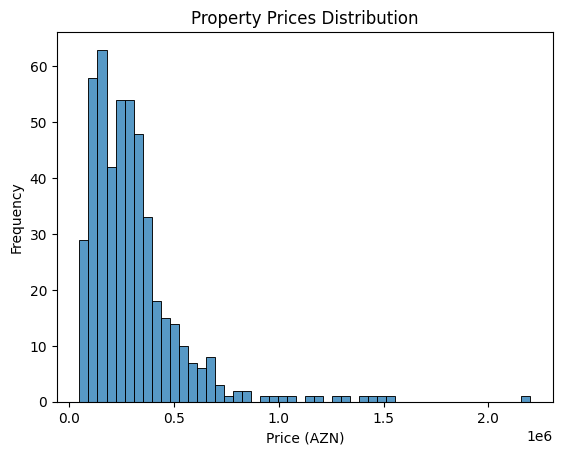

In [9]:
price_data = df['price']

sns.histplot(price_data, bins=50)
plt.title('Property Prices Distribution')
plt.xlabel('Price (AZN)')
plt.ylabel('Frequency')
plt.show()


C:\Users\aliye\AppData\Local\Temp\ipykernel_17708\1208470708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.index, y=location_counts.values, palette='viridis')


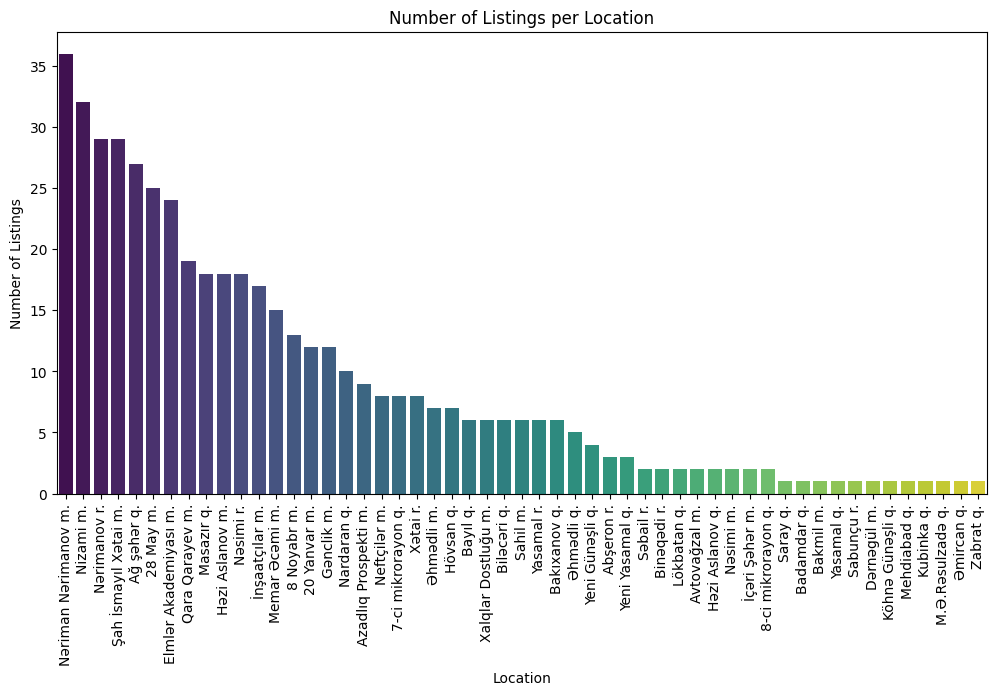

In [10]:
location_counts = df['location'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette='viridis')
plt.title('Number of Listings per Location')
plt.xlabel('Location')
plt.ylabel('Number of Listings')
plt.xticks(rotation=90)
plt.show()

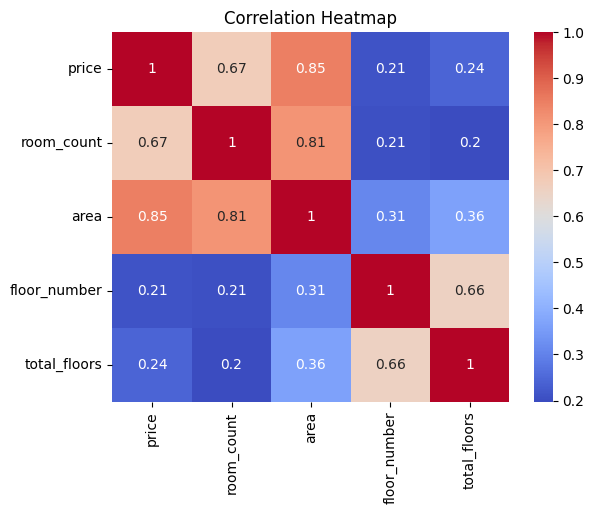

In [11]:
corr = df[['price', 'room_count', 'area', 'floor_number', 'total_floors']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Number of outliers: 28


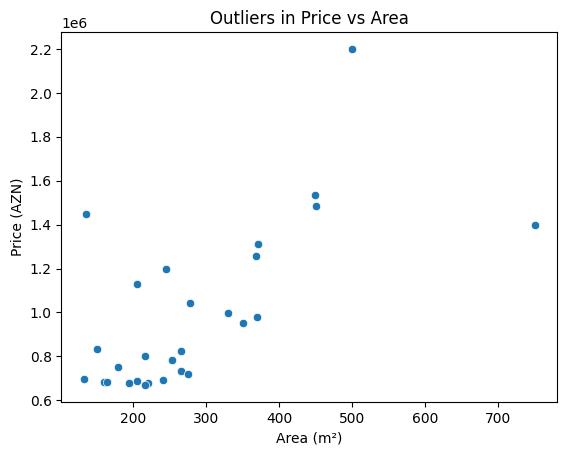

In [12]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR))]

print(f"Number of outliers: {len(outliers)}")
sns.scatterplot(x='area', y='price', data=outliers)
plt.title('Outliers in Price vs Area')
plt.xlabel('Area (m²)')
plt.ylabel('Price (AZN)')
plt.show()
